# Segmentation Pulmonaire par U-Net

Ce notebook entraîne un modèle U-Net pour segmenter automatiquement les poumons sur des radiographies thoraciques (CXR).  
L'objectif est de pouvoir appliquer un mask sur **n'importe quelle nouvelle image** pour isoler les poumons avant classification.

**Pipeline** : Image CXR → U-Net → Mask prédit → Image masquée → Classifieur

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Chargement des données

On collecte toutes les paires (image, mask) depuis les 4 classes.  
Pour la segmentation, la classe de pathologie n'a pas d'importance — on veut juste segmenter les poumons.

In [12]:
# On monte les données dans content/ (pour Google Colab)

from google.colab import drive
import subprocess
drive.mount('/content/drive')

dataset_archive = '/content/drive/MyDrive/DS_COVID/archive_dataset.zip'


print("📦 Extraction dataset...")
os.makedirs('./data/raw/', exist_ok=True)
subprocess.run(['unzip', '-o', '-q', dataset_archive, '-d',  './data/raw/'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Extraction dataset...


CompletedProcess(args=['unzip', '-o', '-q', '/content/drive/MyDrive/DS_COVID/archive_dataset.zip', '-d', './data/raw/'], returncode=0)

In [13]:
BASE_DIR = "/content/data/raw/COVID-19_Radiography_Dataset"
CLASSES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
IMG_SIZE = 256

image_paths = []
mask_paths = []

for cls in CLASSES:
    img_dir = os.path.join(BASE_DIR, cls, "images")
    mask_dir = os.path.join(BASE_DIR, cls, "masks")
    for fname in sorted(os.listdir(img_dir)):
        img_path = os.path.join(img_dir, fname)
        msk_path = os.path.join(mask_dir, fname)
        if os.path.exists(msk_path):
            image_paths.append(img_path)
            mask_paths.append(msk_path)

print(f"Total de paires image/mask : {len(image_paths)}")
print(f"Type des chemins : {type(image_paths[0])}")
print(f"Exemple : {image_paths[0]}")

Total de paires image/mask : 21165
Type des chemins : <class 'str'>
Exemple : /content/data/raw/COVID-19_Radiography_Dataset/COVID/images/COVID-1.png


## 2. Visualisation de quelques paires

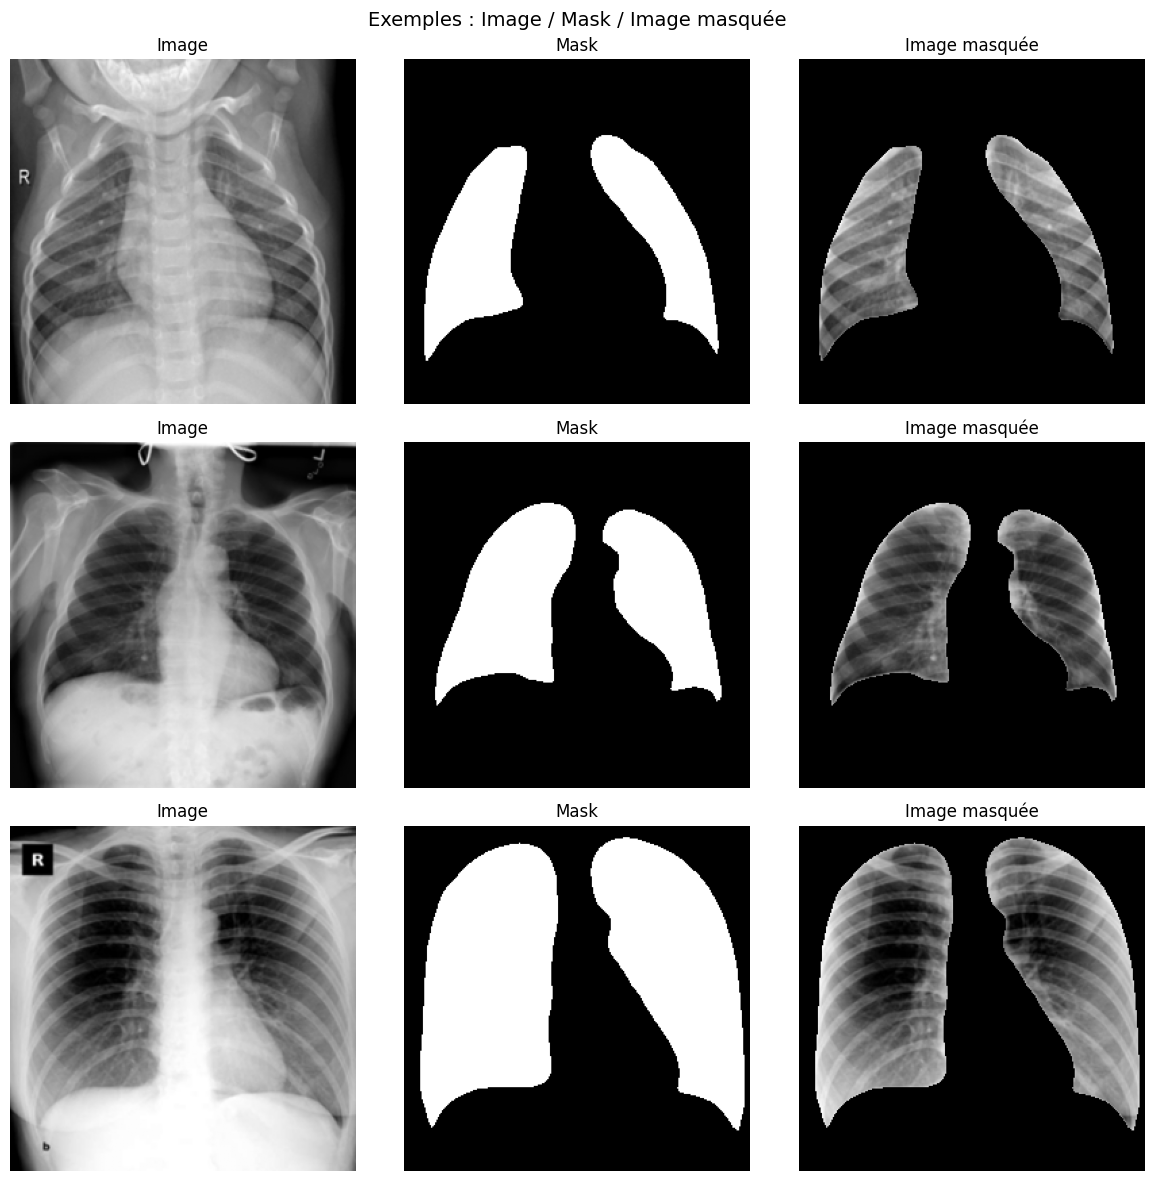

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
indices = np.random.choice(len(image_paths), 3, replace=False)

for i, idx in enumerate(indices):
    img = cv2.imread(image_paths[idx], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    
    axes[i, 0].imshow(img_resized, cmap="gray")
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask_resized, cmap="gray")
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")
    
    masked = img_resized * (mask_resized > 127).astype(np.uint8)
    axes[i, 2].imshow(masked, cmap="gray")
    axes[i, 2].set_title("Image masquée")
    axes[i, 2].axis("off")

plt.suptitle("Exemples : Image / Mask / Image masquée", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Préparation du dataset TensorFlow

On utilise `tf.data` pour charger les images à la volée (éviter de tout mettre en RAM).

In [15]:
# Split train / val / test (80 / 10 / 10)
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)
val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    test_imgs, test_masks, test_size=0.5, random_state=42
)

print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

Train: 16932 | Val: 2116 | Test: 2117


In [16]:
BATCH_SIZE = 64

def load_and_preprocess(img_path, mask_path):
    # Charger l'image en grayscale
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    
    # Charger le mask (prendre un seul canal)
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0
    
    return img, mask

def make_dataset(img_paths, mask_paths, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_imgs, train_masks, BATCH_SIZE, shuffle=True)
val_ds = make_dataset(val_imgs, val_masks, BATCH_SIZE, shuffle=False)
test_ds = make_dataset(test_imgs, test_masks, BATCH_SIZE, shuffle=False)

# Vérification
for imgs, masks in train_ds.take(1):
    print(f"Batch images : {imgs.shape}, Batch masks : {masks.shape}")

Batch images : (64, 256, 256, 1), Batch masks : (64, 256, 256, 1)


## 4. Architecture U-Net

U-Net classique avec un encodeur (downsampling) et un décodeur (upsampling) avec skip connections.

In [17]:
def conv_block(x, n_filters):
    x = layers.Conv2D(n_filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(n_filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def encoder_block(x, n_filters):
    skip = conv_block(x, n_filters)
    pool = layers.MaxPooling2D(2)(skip)
    return skip, pool

def decoder_block(x, skip, n_filters):
    x = layers.Conv2DTranspose(n_filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, n_filters)
    return x

def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)
    
    # Encodeur
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)
    
    # Bottleneck
    b = conv_block(p4, 1024)
    
    # Décodeur
    d4 = decoder_block(b, s4, 512)
    d3 = decoder_block(d4, s3, 256)
    d2 = decoder_block(d3, s2, 128)
    d1 = decoder_block(d2, s1, 64)
    
    # Sortie : 1 canal, activation sigmoid pour proba [0, 1]
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d1)
    
    return keras.Model(inputs, outputs, name="UNet")

model = build_unet()
model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

## 5. Métriques et Loss

On utilise le **Dice coefficient** comme métrique principale (standard en segmentation) et une combinaison **BCE + Dice Loss**.

In [18]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin) - intersection
    return (intersection + smooth) / (union + smooth)

## 6. Compilation et Entraînement

In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_unet_lung_seg.keras",
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

In [ ]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30


: 

## 7. Courbes d'entraînement

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_title("Loss (BCE + Dice)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Dice
axes[1].plot(history.history["dice_coefficient"], label="Train")
axes[1].plot(history.history["val_dice_coefficient"], label="Val")
axes[1].set_title("Dice Coefficient")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# IoU
axes[2].plot(history.history["iou_metric"], label="Train")
axes[2].plot(history.history["val_iou_metric"], label="Val")
axes[2].set_title("IoU")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("Courbes d'entraînement U-Net", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Évaluation sur le jeu de test

In [ ]:
results = model.evaluate(test_ds)
print(f"\nTest Loss     : {results[0]:.4f}")
print(f"Test Dice     : {results[1]:.4f}")
print(f"Test IoU      : {results[2]:.4f}")

## 9. Prédictions visuelles sur le jeu de test

In [ ]:
# Prendre un batch du test set
test_batch_imgs, test_batch_masks = next(iter(test_ds))
predictions = model.predict(test_batch_imgs)

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
columns = ["Image", "Mask réel", "Mask prédit", "Image masquée (prédit)"]

for j, col in enumerate(columns):
    axes[0, j].set_title(col, fontsize=13, fontweight="bold")

for i in range(5):
    img = test_batch_imgs[i].numpy().squeeze()
    true_mask = test_batch_masks[i].numpy().squeeze()
    pred_mask = (predictions[i].squeeze() > 0.5).astype(np.float32)
    
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(true_mask, cmap="gray")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].axis("off")
    
    masked_img = img * pred_mask
    axes[i, 3].imshow(masked_img, cmap="gray")
    axes[i, 3].axis("off")

plt.suptitle("Prédictions U-Net sur le test set", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Sauvegarde du modèle

In [ ]:
SAVE_DIR = os.path.join("..", "models")
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, "unet_lung_segmentation.keras"))
print("Modèle sauvegardé dans", SAVE_DIR)

## 11. Fonction utilitaire : masquer une nouvelle image

Cette fonction prend n'importe quelle radiographie thoracique et lui applique le mask prédit par le U-Net.

In [ ]:
def segment_and_mask(image_path, model, img_size=256, threshold=0.5):
    """
    Charge une image CXR, prédit le mask pulmonaire, et retourne l'image masquée.
    
    Returns:
        original: image originale redimensionnée
        pred_mask: mask binaire prédit
        masked: image avec uniquement les poumons
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_norm = img_resized.astype(np.float32) / 255.0
    
    # Prédiction
    input_tensor = img_norm[np.newaxis, ..., np.newaxis]  # (1, H, W, 1)
    pred = model.predict(input_tensor, verbose=0)[0].squeeze()
    pred_mask = (pred > threshold).astype(np.uint8)
    
    masked = img_resized * pred_mask
    
    return img_resized, pred_mask, masked


# Démo sur une image du dataset
demo_path = image_paths[0]
original, pred_mask, masked = segment_and_mask(demo_path, model)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(original, cmap="gray")
axes[0].set_title("Image originale")
axes[0].axis("off")
axes[1].imshow(pred_mask, cmap="gray")
axes[1].set_title("Mask prédit")
axes[1].axis("off")
axes[2].imshow(masked, cmap="gray")
axes[2].set_title("Image masquée")
axes[2].axis("off")
plt.suptitle(f"Segmentation sur : {os.path.basename(demo_path)}", fontsize=13)
plt.tight_layout()
plt.show()